In [ ]:
#s1
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Generate Synthetic Data
np.random.seed(42)
n_rows = 250

data = {
    'Employee_ID': range(101, 101 + n_rows),
    'Age': np.random.randint(22, 60, n_rows),
    'Gender': np.random.choice(['Male', 'Female'], n_rows),
    'Education': np.random.choice(['Bachelor', 'Master', 'PhD'], n_rows),
    'Department': np.random.choice(['IT', 'HR', 'Sales', 'Marketing', 'Finance'], n_rows),
    'Experience': np.random.randint(0, 35, n_rows),
    'Working_Hours': np.random.randint(35, 60, n_rows),
    'Performance_Score': np.random.randint(1, 11, n_rows),
    'Projects_Completed': np.random.randint(1, 20, n_rows)
}

df = pd.DataFrame(data)

# Logic-based Salary: Base 30k + Exp*2000 + Score*1500 + Noise
df['Salary'] = (30000 + (df['Experience'] * 2200) +
                (df['Performance_Score'] * 1200) +
                np.random.normal(0, 5000, n_rows)).astype(int)

# 2. Categorical Salary for Classification
def categorize_salary(val):
    if val > 85000: return 'High'
    elif val > 55000: return 'Medium'
    else: return 'Low'

df['Salary_Category'] = df['Salary'].apply(categorize_salary)
df.to_csv('employee_data.csv', index=False)

# 3. Preprocessing
le = LabelEncoder()
for col in ['Gender', 'Education', 'Department']:
    df[col] = le.fit_transform(df[col])

X = df.drop(['Employee_ID', 'Salary', 'Salary_Category'], axis=1)
y_reg = df['Salary']
y_clf = le.fit_transform(df['Salary_Category']) # 0: High, 1: Low, 2: Medium

X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#s2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset you created in Step 1
df = pd.read_csv('/content/employee_data.csv')

# --- 1. Handle Missing Values ---
# Since we generated the data, there might not be any,
# but this is how you handle them if they existed:
df.fillna(df.median(numeric_only=True), inplace=True) # Fill numbers with median
df.fillna(df.mode().iloc[0], inplace=True)           # Fill strings with mode

# --- 2. Remove Duplicates ---
df.drop_duplicates(inplace=True)

# --- 3. Encode Categorical Values ---
# Models need numbers, not words (e.g., 'Male' -> 0, 'Female' -> 1)
le = LabelEncoder()
categorical_cols = ['Gender', 'Education', 'Department']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Also encode the Salary_Category for Classification (Step 3B)
df['Salary_Category_Encoded'] = le.fit_transform(df['Salary_Category'])

# --- 4. Define Features (X) and Target (y) ---
# X = Everything except the ID and the target values
X = df.drop(['Employee_ID', 'Salary', 'Salary_Category', 'Salary_Category_Encoded'], axis=1)

# y_reg for Regression (Linear Regression/Random Forest)
y_reg = df['Salary']

# y_clf for Classification (Logistic Regression)
y_clf = df['Salary_Category_Encoded']

# --- 5. Perform Train-Test Split ---
# We split 80% for training and 20% for testing
X_train, X_test, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# --- 6. Feature Scaling ---
# This normalizes the range of features so 'Age' (20-60) doesn't
# outweigh 'Experience' (0-10) simply because the numbers are larger.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing Complete!")
print(f"Training set size: {X_train_scaled.shape[0]} rows")
print(f"Testing set size: {X_test_scaled.shape[0]} rows")

Preprocessing Complete!
Training set size: 200 rows
Testing set size: 50 rows


In [ ]:
#s3.1
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Initialize the Model
lr_model = LinearRegression()

# 2. Train the Model
# Note: We use the scaled training data (X_train_scaled) and y_train_reg
lr_model.fit(X_train_scaled, y_train_reg)

# 3. Make Predictions on the Test Set
y_pred_lr = lr_model.predict(X_test_scaled)

# 4. Model Evaluation (Quick Preview for Step 5)
mae = mean_absolute_error(y_test_reg, y_pred_lr)
mse = mean_squared_error(y_test_reg, y_pred_lr)
r2 = r2_score(y_test_reg, y_pred_lr)

print("--- Linear Regression Results ---")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

# 5. Quick Comparison: Actual vs Predicted (First 5 rows)
comparison_df = pd.DataFrame({'Actual': y_test_reg, 'Predicted': y_pred_lr})
print("\nFirst 5 Predictions:")
print(comparison_df.head())

--- Linear Regression Results ---
Mean Absolute Error (MAE): $4317.44
Mean Squared Error (MSE): 25926887.44
R² Score: 0.9526

First 5 Predictions:
     Actual      Predicted
142   85282   89897.332551
6    109812  106766.924445
97    81518   78975.502473
60    74142   65565.039171
112   47416   52872.667247


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


--- Logistic Regression Results ---
Accuracy Score: 82.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        26
           1       0.73      0.89      0.80         9
           2       0.69      0.73      0.71        15

    accuracy                           0.82        50
   macro avg       0.79      0.82      0.80        50
weighted avg       0.83      0.82      0.82        50



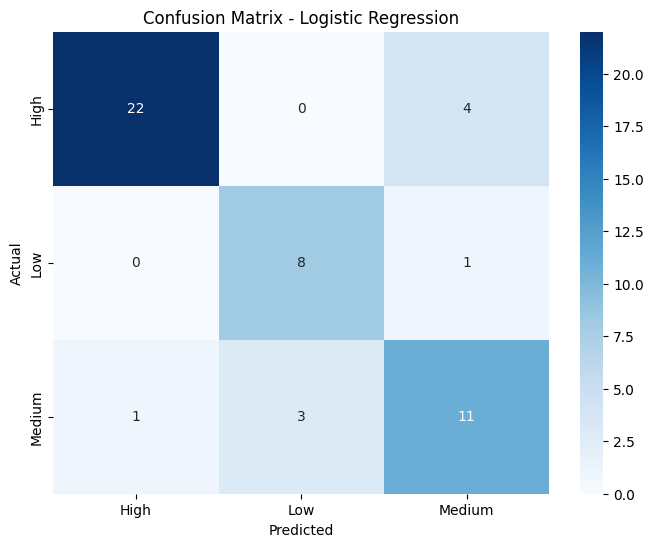

In [ ]:
#3.2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Initialize the Model
# 'multi_class' is set to 'ovr' or 'multinomial' for 3 categories
log_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

# 2. Train the Model
# Use X_train_scaled and the categorical target y_train_clf
log_model.fit(X_train_scaled, y_train_clf)

# 3. Make Predictions
y_pred_log = log_model.predict(X_test_scaled)

# 4. Evaluation
accuracy = accuracy_score(y_test_clf, y_pred_log)
conf_matrix = confusion_matrix(y_test_clf, y_pred_log)

print("--- Logistic Regression Results ---")
print(f"Accuracy Score: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_log))

# 5. Visualizing the Confusion Matrix (Briefly for Step 5)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High', 'Low', 'Medium'],
            yticklabels=['High', 'Low', 'Medium'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#s3.3
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# --- A. Random Forest for Regression (Predicting Salary) ---
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_scaled, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

# --- B. Random Forest for Classification (Predicting Category) ---
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_scaled)

print("Random Forest models trained successfully!")

Random Forest models trained successfully!


In [ ]:
#s3.3 Calculate R² for both
r2_linear = r2_score(y_test_reg, y_pred_lr)
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("--- Regression Comparison (R² Score) ---")
print(f"Linear Regression: {r2_linear:.4f}")
print(f"Random Forest:    {r2_rf:.4f}")
print(f"Improvement:      {((r2_rf - r2_linear) / r2_linear) * 100:.2f}%" if r2_rf > r2_linear else "No improvement")

--- Regression Comparison (R² Score) ---
Linear Regression: 0.9526
Random Forest:    0.9235
No improvement


In [ ]:
# s3.3Calculate Accuracy for both
acc_logistic = accuracy_score(y_test_clf, y_pred_log)
acc_rf = accuracy_score(y_test_clf, y_pred_rf_clf)

print("\n--- Classification Comparison (Accuracy) ---")
print(f"Logistic Regression: {acc_logistic * 100:.2f}%")
print(f"Random Forest:       {acc_rf * 100:.2f}%")


--- Classification Comparison (Accuracy) ---
Logistic Regression: 82.00%
Random Forest:       82.00%


/tmp/ipykernel_9992/2196210170.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


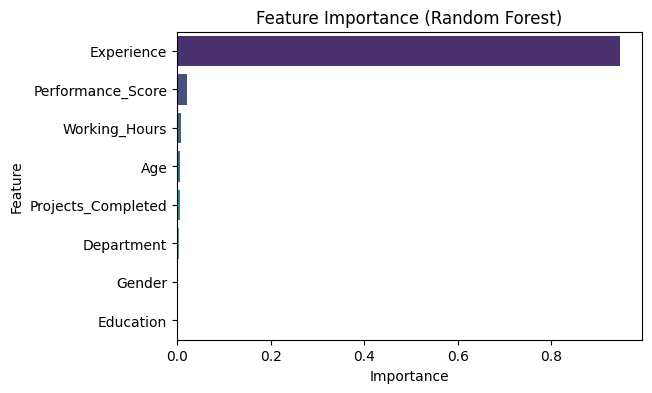

In [ ]:
#s3.3
import matplotlib.pyplot as plt

# Get importance from the Random Forest Regressor
importances = rf_reg.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.show()

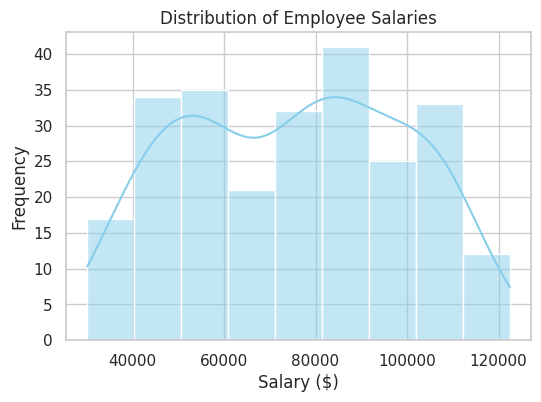

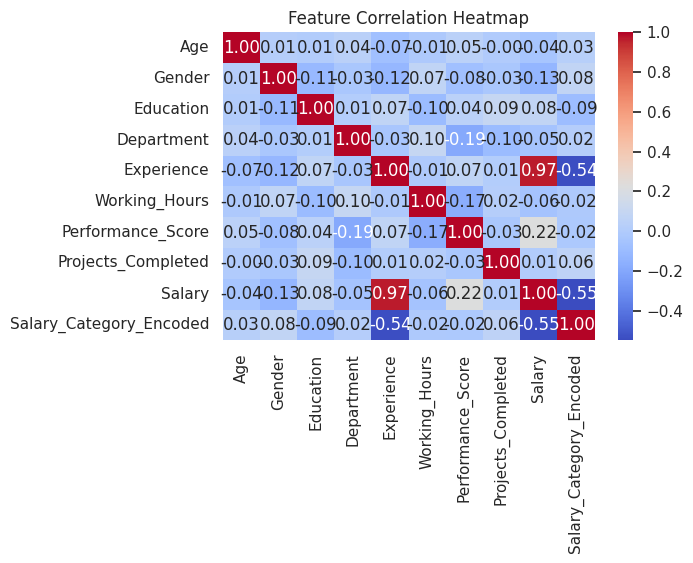

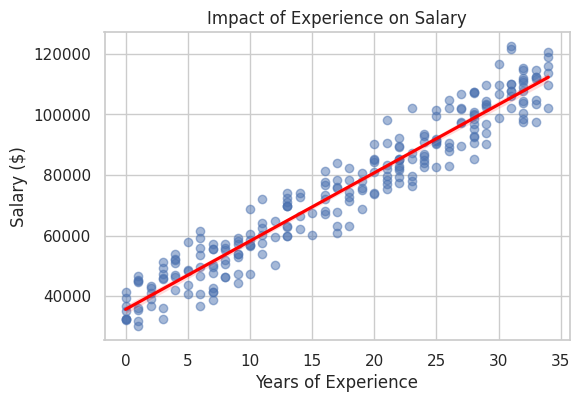

/tmp/ipykernel_9992/4155193697.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Salary', palette='Set2')


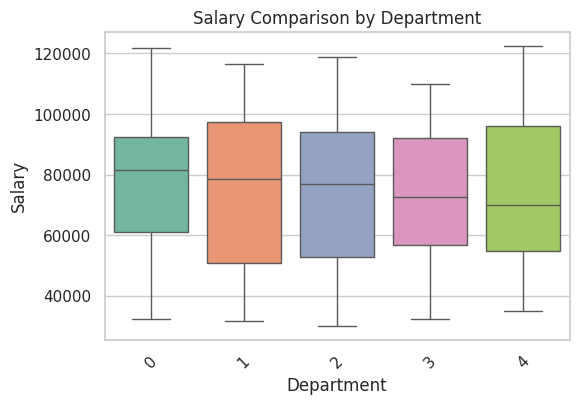

/tmp/ipykernel_9992/4155193697.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


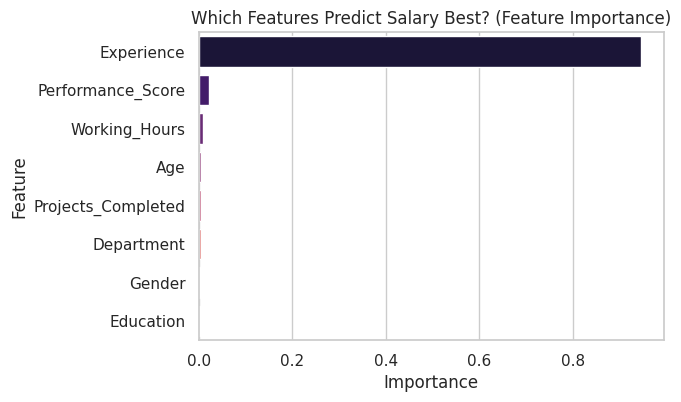

In [ ]:
#step4
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Salary Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Salary'], kde=True, color='skyblue')
plt.title('Distribution of Employee Salaries')
plt.xlabel('Salary ($)')
plt.ylabel('Frequency')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(6,4))
# We only calculate correlation for numeric columns
numeric_df = df.drop(['Employee_ID', 'Salary_Category'], axis=1)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. Experience vs Salary
plt.figure(figsize=(6,4))
sns.regplot(data=df, x='Experience', y='Salary', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Impact of Experience on Salary')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.show()

# 4. Department-wise Comparison
plt.figure(figsize=(6,4))
# Using the original dataframe (before label encoding) makes labels readable
# If you already encoded it, use the CSV to reload or map labels back
sns.boxplot(data=df, x='Department', y='Salary', palette='Set2')
plt.title('Salary Comparison by Department')
plt.xticks(rotation=45)
plt.show()

# 5. Feature Importance Graph
# (Using the Random Forest Regressor we trained in Step 3C)
importances = rf_reg.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Which Features Predict Salary Best? (Feature Importance)')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Data for Regression Comparison
reg_metrics = {
    'Metric': ['MAE', 'MSE', 'R² Score'],
    'Linear Regression': [
        mean_absolute_error(y_test_reg, y_pred_lr),
        mean_squared_error(y_test_reg, y_pred_lr),
        r2_score(y_test_reg, y_pred_lr)
    ],
    'Random Forest': [
        mean_absolute_error(y_test_reg, y_pred_rf_reg),
        mean_squared_error(y_test_reg, y_pred_rf_reg),
        r2_score(y_test_reg, y_pred_rf_reg)
    ]
}

df_reg_compare = pd.DataFrame(reg_metrics)
print("--- Regression Model Evaluation ---")
print(df_reg_compare)

--- Regression Model Evaluation ---
     Metric  Linear Regression  Random Forest
0       MAE       4.317440e+03   5.531522e+03
1       MSE       2.592689e+07   4.182071e+07
2  R² Score       9.525646e-01   9.234855e-01
--- Regression Model Evaluation ---
     Metric  Linear Regression  Random Forest
0       MAE       4.317440e+03   5.531522e+03
1       MSE       2.592689e+07   4.182071e+07
2  R² Score       9.525646e-01   9.234855e-01



--- Classification Model Evaluation ---
Logistic Regression Accuracy: 0.8200
Random Forest Accuracy:      0.8200


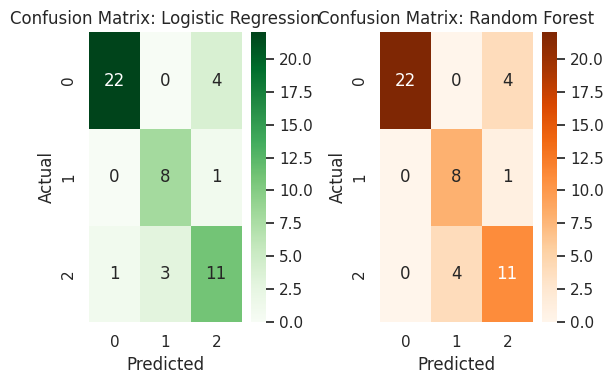

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Accuracy Comparison
acc_log = accuracy_score(y_test_clf, y_pred_log)
acc_rf = accuracy_score(y_test_clf, y_pred_rf_clf)

print("\n--- Classification Model Evaluation ---")
print(f"Logistic Regression Accuracy: {acc_log:.4f}")
print(f"Random Forest Accuracy:      {acc_rf:.4f}")

# 3. Confusion Matrix Visualization
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

# Logistic Regression Matrix
sns.heatmap(confusion_matrix(y_test_clf, y_pred_log), annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title('Confusion Matrix: Logistic Regression')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

# Random Forest Matrix
sns.heatmap(confusion_matrix(y_test_clf, y_pred_rf_clf), annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title('Confusion Matrix: Random Forest')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()